In [70]:
import os
import cv2
import numpy as np
import mediapipe as mp
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tqdm import tqdm
from tqdm.keras import TqdmCallback
import joblib
import matplotlib.pyplot as plt
import tensorflowjs as tfjs

In [71]:
target_dir = 'pull-up'

for dirname, _, filenames in os.walk(target_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pull-up/pull up_4.mp4
pull-up/pull up_14.mp4
pull-up/pull up_15.mp4
pull-up/pull up_5.mp4
pull-up/pull up_7.mp4
pull-up/pull up_17.mp4
pull-up/pull up_16.mp4
pull-up/pull up_6.mp4
pull-up/pull up_2.mp4
pull-up/pull up_12.mp4
pull-up/pull up_13.mp4
pull-up/pull up_3.mp4
pull-up/pull up_1.mp4
pull-up/pull up_11.mp4
pull-up/pull up_10.mp4
pull-up/pull up_21.mp4
pull-up/pull up_20.mp4
pull-up/pull up_22.mp4
pull-up/pull up_23.mp4
pull-up/pull up_26.mp4
pull-up/pull up_8.mp4
pull-up/pull up_18.mp4
pull-up/pull up_24.mp4
pull-up/pull up_25.mp4
pull-up/pull up_19.mp4
pull-up/pull up_9.mp4


# Pose Setup

In [72]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=1, enable_segmentation=False)

I0000 00:00:1764842320.291701  248620 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M4


# Feature Extraction & Keypoint

##### Function for extract keypoints from the video

In [73]:
def extract_keypoints(path):
    cap = cv2.VideoCapture(path)
    keypts_all = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = pose.process(img_rgb)
        if res.pose_landmarks:
            keypts = np.array([[lm.x, lm.y, lm.z] for lm in res.pose_landmarks.landmark])
            keypts_all.append(keypts)
    cap.release()
    return np.array(keypts_all)

##### Calculate Angle

In [74]:
def calculate_angle(A, B, C):
    vba = A - B
    vbc = C - B

    dot_product = np.dot(vba,vbc)
    magnitude = np.linalg.norm(vba) * np.linalg.norm(vbc)
    cos_angle = dot_product / (magnitude + 1e-6)
    angle_rad = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    return np.degrees(angle_rad)

##### Feature Extraction

In [75]:
def extract_features_pullup(keypts_seq):
    if len(keypts_seq) == 0:
        return np.zeros(30)
    
    required_indices = max(27, 28) 
    
    if len(keypts_seq[0]) < required_indices + 1:
        return np.zeros(30)
    
    left_elbow   = [calculate_angle(f[11], f[13], f[15]) for f in keypts_seq] 
    right_elbow  = [calculate_angle(f[12], f[14], f[16]) for f in keypts_seq] 
    left_shoulder  = [calculate_angle(f[23], f[11], f[13]) for f in keypts_seq] 
    right_shoulder = [calculate_angle(f[24], f[12], f[14]) for f in keypts_seq] 
    left_hip     = [calculate_angle(f[11], f[23], f[25]) for f in keypts_seq] 
    right_hip    = [calculate_angle(f[12], f[24], f[26]) for f in keypts_seq]

    # sebenarnya opsional tapi untuk pull up yang terkadang ada menekuk lutut jadi ditambahkan
    left_knee = [calculate_angle(f[23], f[25], f[27]) for f in keypts_seq]
    right_knee = [calculate_angle(f[24], f[26], f[28]) for f in keypts_seq]

    angle_sequences = [left_elbow, right_elbow, left_shoulder, right_shoulder, left_hip, right_hip, left_knee, right_knee] 

    features = []
    for seq in angle_sequences:
        features.extend([np.mean(seq), np.std(seq), np.min(seq), np.max(seq), np.ptp(seq)])

    return np.array(features)

In [76]:
def extract_features_video(path):
    keypts_all = extract_keypoints(path)
    return extract_features_pullup(keypts_all)

# 1. Data Preparation

In [77]:
base_dir = "pull-up" 
output_dir = "models/pullup-models" 
os.makedirs(output_dir, exist_ok=True)

In [78]:
print(f"Isi direktori {base_dir}: {os.listdir(base_dir)[:5]}...")

Isi direktori pull-up: ['pull up_4.mp4', 'pull up_14.mp4', 'pull up_15.mp4', 'pull up_5.mp4', 'pull up_7.mp4']...


In [79]:
features = []
for vid in tqdm(os.listdir(base_dir)):
    if not (vid.lower().endswith(".mp4") or vid.lower().endswith(".mov")): continue
    video_path = os.path.join(base_dir, vid)    
    feat = extract_features_video(video_path) 
    if np.allclose(feat, 0): continue
    features.append(feat)

  0%|          | 0/26 [00:00<?, ?it/s]W0000 00:00:1764842320.355008  322106 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1764842320.365672  322106 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
100%|██████████| 26/26 [01:40<00:00,  3.86s/it]


In [80]:
x = np.vstack(features)
print(f"Feature sample: {x.shape[0]}")

Feature sample: 26


# 2. Normalization

In [81]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
joblib.dump(scaler, os.path.join(output_dir, "pullup_scaler.pkl"))

['models/pullup-models/pullup_scaler.pkl']

# 3. Model Building

In [82]:
inputs = layers.Input(shape=(x_scaled.shape[1], ))
x = layers.GaussianNoise(0.02)(inputs)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x) 
x = layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(x_scaled.shape[1], activation="linear")(x)

In [83]:
autoencoder = models.Model(inputs, outputs)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_2                │ (None, 40)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,488 (40.97 KB)

 Trainable params: 10,488 (40.97 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

# 4. Model Training

**- early_stopping** digunakan untuk menghentikan proses training lebih cepat ketika model sudah tidak mengalami perbaikan lagi. agar model tidak overfitting <br>
**- reduce_lr** digunakan untuk menurunkan learning rate secara otomatis ketika model sudah tidak membaik lagi.

In [85]:
early_stopping = callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=0)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=0)

In [86]:
history = autoencoder.fit(x_scaled, x_scaled, epochs=300, batch_size=8, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4718 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4325 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4046 - val_loss: 0.3875 - learning_rate: 0.0010
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3721 - val_loss: 0.3642 - learning_rate: 0.0010
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3611 - val_loss: 0.3341 - learning_rate: 0.0010
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3212 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2815 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2320 - val_loss: 0.2264 - learning_rate: 0.0010
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2052 - val_loss: 0.2033 - learning_rate: 0.0010
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━

# 5. Plotting

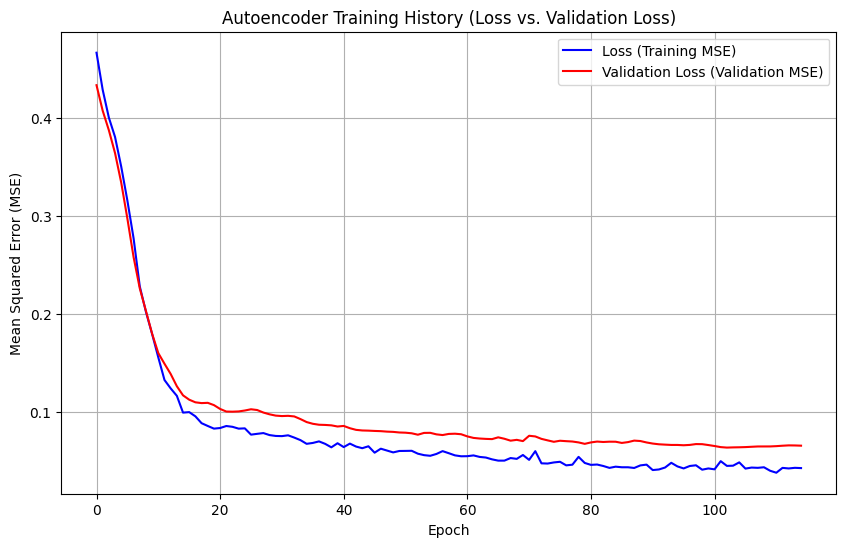

In [87]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Loss (Training MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (Validation MSE)', color='red')
plt.title('Autoencoder Training History (Loss vs. Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Save Model

In [88]:
path = os.path.join(output_dir, "pullup_autoencoder.keras")
autoencoder.save(path)

tetap save tfjs karena kami berencana menggunakan react.js untuk frontend

In [89]:
tfjs_output = os.path.join(output_dir, "pullup_tfjs")
tfjs.converters.save_keras_model(autoencoder, tfjs_output)

failed to lookup keras version from the file,
    this is likely a weight only file


In [102]:
recon = autoencoder.predict(x_scaled, verbose=0)
train_mse_vals = np.mean(np.square(x_scaled - recon), axis=1)
np.save(os.path.join(output_dir, "pullup_train_mse_stats.npy"), train_mse_vals)

# 7. Testing

In [96]:
test_video = "41 pull ups.mp4"

In [104]:
scaler_loaded = joblib.load(os.path.join(output_dir, "pullup_scaler.pkl"))
autoencoder_loaded = tf.keras.models.load_model(os.path.join(output_dir, "pullup_autoencoder.keras"))
train_mse_vals_loaded  = np.load(os.path.join(output_dir, "pullup_train_mse_stats.npy"))

In [100]:
feat = extract_features_video(test_video)

In [101]:
if np.allclose(feat, 0):
    score = 5.0  
else:
    feat_scaled = scaler_loaded.transform(feat.reshape(1, -1))
    reconstruction = autoencoder_loaded.predict(feat_scaled, verbose=0)
    mse = np.mean(np.square(feat_scaled - reconstruction))
    low, high = np.percentile(train_mse_vals_loaded, [5, 95])
    max_mse = high * 3 
    
    if mse <= low:
        score = 100
    elif mse >= max_mse:
        score = 5
    else:
        score = 100 - 95 * (mse - low) / (max_mse - low)
    
    score = float(np.clip(score, 5, 100))

print(f"Score for {test_video}: {score:.2f}/100")

Score for 41 pull ups.mp4: 92.10/100
